# Домашнее задание 5

Решение каждой задачи необходимо поместить после её условия.

Пожалуйста, пишите свои решения чётко и понятно. 
При полном запуске Вашего решения (Kernel -> Restart & Run All) все ячейки должны выполняться без ошибок. 

## Задача 1 (10 pts)

Пусть задан набор из $N$ пар точек в $n$-мерном пространстве $x_1, \ldots , x_N$ и $y_1, \ldots, y_N$.
Также даны расстояния $d_1, \ldots , d_N$ между ними. Необходимо найти такую матрицу $M \in \mathbb{S}^n_+$, что 
$d_i \approx d(x_i, y_i) = \sqrt{(x_i − y_i)M(x_i − y_i)}$. 
Таким образом, целевой функцией в
данной задаче является следующая функция
$$ 
\min_{M \in \mathbb{S}^n_+} \frac{1}{N}\sum_{i=1}^N (d_i - d(x_i, y_i))^2.
$$

В данном случае при старте из точки $M_0 \in \mathbb{S}^n_+$ тестируемые методы не должен выводить промежуточные точки $M_k$ за границы допустимого множества, но не забудьте это проверять и модифицируйте размер шага соответственно.

Сравните сходимость градиентного спуска, метода тяжёлого шарика и быстрого градиентного метода для решения этой задачи.

Также проверьте ошибку на тестовых данных ```d_test, X_test, Y_test```. Прокомментируйте результат.

In [1]:
from abc import ABC, abstractmethod
from typing import Tuple, List

from scipy import linalg as la
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(8)

### Методы оптимизации 

In [2]:
class GradientMethod(ABC):
    @abstractmethod
    def step(self, x: np.ndarray, grad_f: np.ndarray) -> np.ndarray:
        pass

    @abstractmethod
    def reset(self):
        pass


class GradientDescent(GradientMethod):
    def __init__(self, alpha: float):
        self.alpha = alpha

    def step(self, x: np.ndarray, grad_f: np.ndarray) -> np.ndarray:
        return x - self.alpha * grad_f

    def reset(self):
        pass


class HeavyBall(GradientMethod):
    def __init__(self, alpha: float, beta: float):
        self.alpha = alpha
        self.beta = beta
        self.x_prev = None

    def step(self, x: np.ndarray, grad_f: np.ndarray) -> np.ndarray:
        if self.x_prev is None:
            self.x_prev = x
        x_new = x - self.alpha * grad_f + self.beta * (x - self.x_prev)
        self.x_prev = x
        return x_new

    def reset(self):
        self.x_prev = None


class Nesterov(GradientMethod):
    def __init__(self, alpha: float, beta: float, restart: int):
        self.alpha = alpha
        self.beta = beta
        self.restart = restart
        self.x_prev = None
        self.steps_done = 0

    def step(self, x: np.ndarray, grad_f: np.ndarray) -> np.ndarray:
        if self.x_prev is None or self.steps_done % self.restart == 0:
            self.x_prev = x
        self.steps_done = (self.steps_done + 1) % self.restart

        y = x + self.beta * (x - self.x_prev)
        x_new = y - self.alpha * grad_f
        self.x_prev = x

        return x_new

    def reset(self):
        self.x_prev = None
        self.steps_done = 0

In [3]:
n = 5  # Dimension
N = 100  # Number of sample
N_test = 10  # Samples for test set

X = np.random.randn(n, N)
Y = np.random.randn(n, N)

X_test = np.random.randn(n, N_test)
Y_test = np.random.randn(n, N_test)

P = np.random.randn(n, n)
P = P.dot(P.T) + np.identity(n)
sqrtP = la.sqrtm(P)

d = np.linalg.norm(sqrtP.dot(X - Y), axis=0)
d = np.maximum(d + np.random.randn(N), 0)
d_test = np.linalg.norm(sqrtP.dot(X_test - Y_test), axis=0)
d_test = np.maximum(d_test + np.random.randn(N_test), 0)

### Решение задачи
Найдём градиент от целевой функции по $M$:
$$
    \frac{\partial f}{\partial M} = \frac{1}{N} \sum_{i}^{N} -2 \left( d_i - \sqrt{(x_i - y_i)M(x_i - y_i)} \right) \frac{(x_i - y_i){(x_i - y_i)}^\top}{2\sqrt{(x_i - y_i)M(x_i - y_i)} }
$$

In [4]:
def dist_loss(X: np.ndarray, Y: np.ndarray, d: np.ndarray, M: np.ndarray) -> float:
    diff = X - Y
    return np.mean((d - np.sqrt(np.diag(diff.T @ M @ diff))) ** 2)


def grad_dist_loss(
    X: np.ndarray, Y: np.ndarray, d: np.ndarray, M: np.ndarray
) -> np.ndarray:
    res = 0
    for i in range(X.shape[1]):
        diff = X[:, i] - Y[:, i]
        dist = np.sqrt(diff @ M @ diff)
        res -= 2 * (d[i] - dist) * np.outer(diff, diff) / (2 * dist)

    return res / X.shape[1]


def to_positive_semidefinite(A: np.ndarray) -> np.ndarray:
    decomp = np.linalg.eig(A)
    q = decomp.eigenvectors
    lambda_ = decomp.eigenvalues
    lambda_ = np.maximum(lambda_, 1e-6)
    return q * lambda_ @ q.T


def solve_dist_problem(
    method: GradientMethod,
    X: np.ndarray,
    Y: np.ndarray,
    d: np.ndarray,
    M_0: np.ndarray,
    tol: float = 1e-6,
    max_steps: int = 100000,
) -> Tuple[np.ndarray, List[float]]:
    history = []
    M = M_0
    for step in range(max_steps):
        grad = grad_dist_loss(X, Y, d, M)
        M = method.step(M, grad)
        M = to_positive_semidefinite(M) # избегаем выхода за область определения
        grad_norm = np.linalg.norm(grad, "fro")
        history.append(grad_norm)
        if grad_norm < tol:
            break
    return M, history


T = np.random.randn(n, n)
M_0 = T.dot(T.T)  # Positive definite matrix

methods = [
    ("GD", GradientDescent(0.1)),
    ("HB", HeavyBall(0.1, 0.9)),
    ("Nesterov", Nesterov(0.1, 0.9, 100)),
]

results = {}
conv_histories = {}

for name, method in methods:
    M, history = solve_dist_problem(method, X_test, Y_test, d_test, M_0)
    results[name] = dist_loss(X_test, Y_test, d_test, M)
    conv_histories[name] = history

### Графики

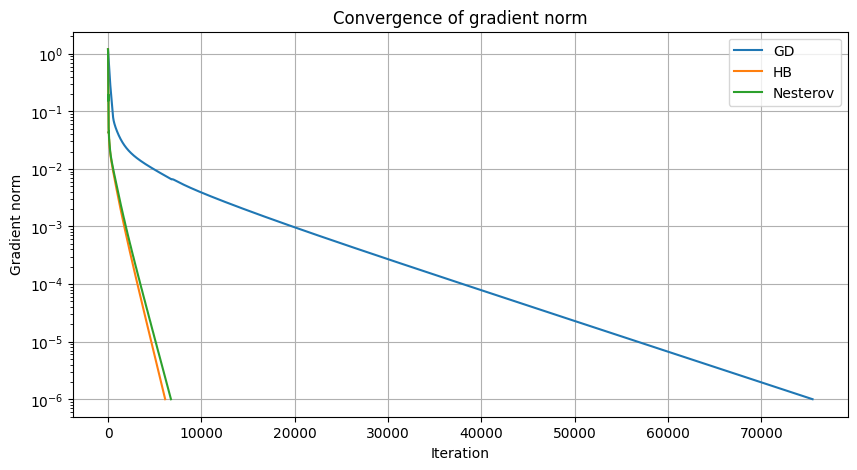

In [5]:
plt.figure(figsize=(10, 5))
for name, history in conv_histories.items():
    plt.semilogy(history, label=name)
plt.legend()
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gradient norm")
plt.title("Convergence of gradient norm")
plt.show()

Как видно из графиков, методы Тяжелого шарика и Нестерова дают значительный прирост к скорости сходимости

## Задача 2 (10 pts)

- (2 pts) Покажите, что градиенты, полученные на двух последовательных шагах градиентного спуска с использованием правила наискорейшего спуска, ортогональны.

- (5 pts) Докажите, что если целевая функция $f(x) = \frac{1}{2}x^{\top}Qx - b^{\top}x$, $Q \in \mathbb{S}^n_{++}$, шаг определяется с помощью наискорейшего спуска и $x^0 - x^*$ параллелен собственному вектору матрицы $Q$, то градиентный спуск сходится за один шаг. 

- Покажите, что для $f(x) = x^{\top}x$ градиентный спуск с выбором шага по правилу наискорейшего спуска сходится за одну итерацию:
    - (1 pts) с использованием предыдущего утверждения
    - (2 pts) прямым вычислением 

### Решения

- Правило наискорейшего спуска: 
  $$ x_{k+1} = x_k - \alpha_k \nabla f(x_k), $$
  $$ \alpha_k = \argmin_{\alpha_k} f(x_k - \alpha_k \nabla f(x_k)) $$
  В точке минимума производная по $\alpha$ равна нулю:
  $$ \frac{\partial}{\partial \alpha} f(x_k - \alpha_k \nabla f(x_k)) = 0 \iff $$
  $$ -\nabla f(x_k - \alpha_k \nabla f(x_k)) \nabla f(x_k) = 0 \iff $$
  $$ -\nabla f(x_{k+1}) \nabla f(x_k) = 0 $$
  Что выполняется только в случае, если градиенты ортогональны.

- Градиент целевой функции по $x$: $Qx - b$. Если $x^0 - x^*$ параллелен собственному вектору 
  матрицы $Q$, то $x^0 - x^* = \delta Sv$, где $S$ - матрица собственных векторов $Q$ из её спектрального разложения $Q = S\Lambda S^{-1}$, $\delta \in \mathbb{R}$, $v$ - единичный вектор с единственным элементом, равным единице. Тогда: 
  $$ x^* = x^0 - \alpha (Qx^0 - b) $$
  $$ x^* = \delta Sv + x^* - \alpha (Q (\delta Sv + x^*) - b) $$
  Подставим из условия оптимальности $x^* = Q^{-1}b$:
  $$ 0 = \delta Sv - \alpha (\delta S\Lambda v + b - b) $$
  $$ \delta Sv = \alpha\delta S\Lambda v $$
  Решением этого уравнения по $\alpha$ является $\alpha = \frac{1}{\lambda}$, где $\lambda$ - собственное значение матрицы $Q$, соответствующее собственному вектору, параллельному $x^0 - x^*$.

- - Целевую функцию можно переформулировать так: 
    $\frac{1}{2} x^\top (2I) x + \bar{0}^\top x$, где $I$ - единичная матрица, $\bar{0}$ - нулевой вектор. Заметим, что для любой ортогональной матрицы $S$ выполняется 
    $$ 2I = S (2I) S^{-1} $$
    Тогда можно существует такая матрица $S$, что одна из её колонок равна $\frac{x^0}{\| x^0 \|_2}$, и эта задача может быть решена за один шаг наискорейшего спуска
  - Градиент целевой функции: $2x$. Для $\alpha = \frac{1}{2}$ всего один шаг даст оптимальное решение: $x_1 = x_0 - \frac{1}{2} 2x_0 = 0$


## Задача 3 (20 pts)

- (5 pts) Оцените константу Липшица градиента для функции

$$
f(w) = \frac12 \|w\|_2^2 + C \frac1m \sum_{i=1}^m \log (1 + \exp(- y_i \langle x_i, w \rangle)) \to \min_w
$$

- (10 pts) Используя найденное значение сравните сходимость метода тяжёлого шарика, метод градиентного спуска с оптимальным постоянным шагом и быстрый градиентный метод. Сделайте вывод о точности оценки констант и их влиянии на скорость сходимости метода тяжёлого шарика. Векторы $x_i$ и скаляры $y_i$ генерируются кодом ниже.
- (5 pts) Добавьте к сравнению метод Ньютона и L-BFGS. Сравнение проведите по сходимости по итерациям и по времени работы.

### Решения

- Градиент целевой функции: 
  $$ \nabla f(w) = w + C \frac{1}{m} \sum_{i=1}^{m} \frac{-y_i x_i}{1 + \exp(-y_i \langle x_i, w \rangle)} $$
  Обозначим $\sigma_i(w) = \frac{1}{1 + \exp(-y_i \langle x_i, w \rangle)}$, тогда разность градиентов в двух точках:
  $$ \nabla f(w_1) - \nabla f(w_2) = w_1 - w_2 + C \frac{1}{m} \sum_{i=1}^{m} -y_i x_i (\sigma_i(w_1) - \sigma_i(w_2))$$
  Для этой её нормы выполняется по неравенству Коши-Буняковского:
  $$ \left\| \nabla f(w_1) - \nabla f(w_2) \right\| \leq \| w_1 - w_2 \| + C \frac{1}{m} \sum_{i=1}^{m} \| x_i \| \| \sigma_i(w_1) - \sigma_i(w_2) \| $$
  Норма градиента $\sigma_i(w)$ ограничена сверху следующим выражением: $\frac{\| x_i \|}{4}$, тогда 
  $$ \left\| \nabla f(w_1) - \nabla f(w_2) \right\| \leq \| w_1 - w_2 \| + C \frac{1}{m} \sum_{i=1}^{m} \frac{\| x_i \|^2}{4} \| w_1 - w_2 \| $$
  Тогда липшецева константа градиента оценивается
  $$ L = \left( 1 + C \frac{1}{4m} \sum_{i=1}^{m} \| x_i \|^2 \right) $$

In [6]:
import time
import sklearn.datasets as skldata

n = 300
m = 1000

X, y = skldata.make_classification(
    n_classes=2, n_features=n, n_samples=m, n_informative=n // 3
)

# Для избежания overflow у чисел при экспонировании,
# нормализуем признаки
X = (X - X.mean(axis=0)) / X.std(axis=0)
# Приводим метки классов к значениям -1 и 1
y = 2 * y.astype(np.float32) - 1
C = 1

### Методы оптимизации

In [7]:
class Newton:
    def __init__(self, alpha: float = 1):
        self.alpha = alpha

    def step(self, x: np.ndarray, grad_f: np.ndarray, hess_f: np.ndarray) -> np.ndarray:
        return x - self.alpha * np.linalg.inv(hess_f) @ grad_f


class LBFGS:
    def __init__(self, m: int = 10, alpha: float = 1):
        self.m = m
        self.alpha = alpha
        self.s = []
        self.y = []

    # Взято с кода семинара 10
    def _get_h(self, grad_f: np.ndarray) -> np.ndarray:
        m = len(self.s)
        if m == 0:
            return -grad_f

        q = grad_f
        alpha = np.zeros(len(self.s))
        rho = np.zeros(len(self.s))
        for i in range(m - 1, -1, -1):
            rho[i] = 1.0 / self.s[i].dot(self.y[i])
            alpha[i] = self.s[i].dot(q) * rho[i]
            q = q - alpha[i] * self.y[i]

        s, y = self.s[-1], self.y[-1]
        r = q * y.dot(s) / y.dot(y)

        for i in range(m):
            beta = rho[i] * self.y[i].dot(r)
            r = r + self.s[i] * (alpha[i] - beta)
        return -r

    def step(self, x: np.ndarray, grad_f: np.ndarray) -> np.ndarray:
        h = self._get_h(grad_f)
        return x + self.alpha * h

    def update(self, s: np.ndarray, y: np.ndarray):
        self.s.append(s)
        self.y.append(y)
        if len(self.s) > self.m:
            self.s.pop(0)
            self.y.pop(0)

Найдем гессиан целевой функции:
$$
H = I + C \frac{1}{m} \sum_{i=1}^{m} x_i x_i^T \sigma_i(w) (1 - \sigma_i(w))
$$
где $\sigma_i(w) = \frac{1}{1 + \exp(-y_i \langle x_i, w \rangle)}$.

In [8]:
def logreg_loss(X: np.ndarray, y: np.ndarray, w: np.ndarray, C: float) -> float:
    return 0.5 * np.sum(w**2) + C * np.mean(np.log(1 + np.exp(-y * (X @ w))))


def grad_logreg_loss(
    X: np.ndarray, y: np.ndarray, w: np.ndarray, C: float
) -> np.ndarray:
    res = 0
    for i in range(X.shape[0]):
        res += -y[i] * X[i] / (1 + np.exp(-y[i] * (X[i] @ w)))

    return w + C * res / X.shape[0]


def hess_logreg_loss(
    X: np.ndarray, y: np.ndarray, w: np.ndarray, C: float
) -> np.ndarray:
    res = 0
    for i in range(X.shape[0]):
        x = X[i]
        sigmoid = 1 / (1 + np.exp(-y[i] * (x @ w)))
        res += sigmoid * (1 - sigmoid) * np.outer(x, x)

    return np.eye(X.shape[1]) + C * res / X.shape[0]


def solve_logreg_problem(
    method: GradientMethod,
    X: np.ndarray,
    y: np.ndarray,
    w_0: np.ndarray,
    C: float,
    tol: float = 1e-6,
    max_steps: int = 100000,
) -> Tuple[np.ndarray, List[Tuple[float, float]]]:
    history = []
    w = w_0
    t_start = time.time()

    for step in range(max_steps):
        grad = grad_logreg_loss(X, y, w, C)
        w = method.step(w, grad)
        grad_norm = np.linalg.norm(grad, 2)
        history.append((grad_norm, time.time() - t_start))
        if grad_norm < tol:
            break

    return w, history


def solve_newton_logreg_problem(
    method: GradientMethod,
    X: np.ndarray,
    y: np.ndarray,
    w_0: np.ndarray,
    C: float,
    tol: float = 1e-6,
    max_steps: int = 100000,
) -> Tuple[np.ndarray, List[Tuple[float, float]]]:
    history = []
    w = w_0
    t_start = time.time()

    for step in range(max_steps):
        grad = grad_logreg_loss(X, y, w, C)
        hess = hess_logreg_loss(X, y, w, C)
        w = method.step(w, grad, hess)
        grad_norm = np.linalg.norm(grad, 2)
        history.append((grad_norm, time.time() - t_start))
        if grad_norm < tol:
            break

    return w, history


def solve_lbfgs_logreg_problem(
    method: GradientMethod,
    X: np.ndarray,
    y: np.ndarray,
    w_0: np.ndarray,
    C: float,
    tol: float = 1e-6,
    max_steps: int = 100000,
) -> Tuple[np.ndarray, List[Tuple[float, float]]]:
    history = []
    w = w_0
    t_start = time.time()
    next_grad = grad_logreg_loss(X, y, w, C)

    for step in range(max_steps):
        next_w = method.step(w, next_grad)
        grad, next_grad = next_grad, grad_logreg_loss(X, y, next_w, C)
        method.update(next_w - w, next_grad - grad)
        w = next_w
        grad_norm = np.linalg.norm(grad, 2)
        history.append((grad_norm, time.time() - t_start))
        if grad_norm < tol:
            break

    return (
        w,
        history,
    )

In [9]:
L = 1 + C / (4 * m) * np.sum([np.linalg.norm(X[i], ord=2) for i in range(m)])
alpha = 1 / L
w_0 = np.random.normal(size=n)

first_order_methods = [
    ("GD", GradientDescent(alpha)),
    ("HB", HeavyBall(alpha, 0.9)),
    ("Nesterov", Nesterov(alpha, 0.9, 10)),
]
newton = Newton()
lbfgs = LBFGS(m=10)

results = {}
conv_histories = {}

for name, method in first_order_methods:
    w, history = solve_logreg_problem(method, X, y, w_0, C)
    results[name] = logreg_loss(X, y, w, C)
    conv_histories[name] = history

w, history = solve_newton_logreg_problem(newton, X, y, w_0, C)
results["Newton"] = logreg_loss(X, y, w, C)
conv_histories["Newton"] = history

w, history = solve_lbfgs_logreg_problem(lbfgs, X, y, w_0, C)
results["LBFGS"] = logreg_loss(X, y, w, C)
conv_histories["LBFGS"] = history

conv_grad_norms = {
    name: [x[0] for x in history] for name, history in conv_histories.items()
}
conv_times = {name: [x[1] for x in history] for name, history in conv_histories.items()}

### Графики

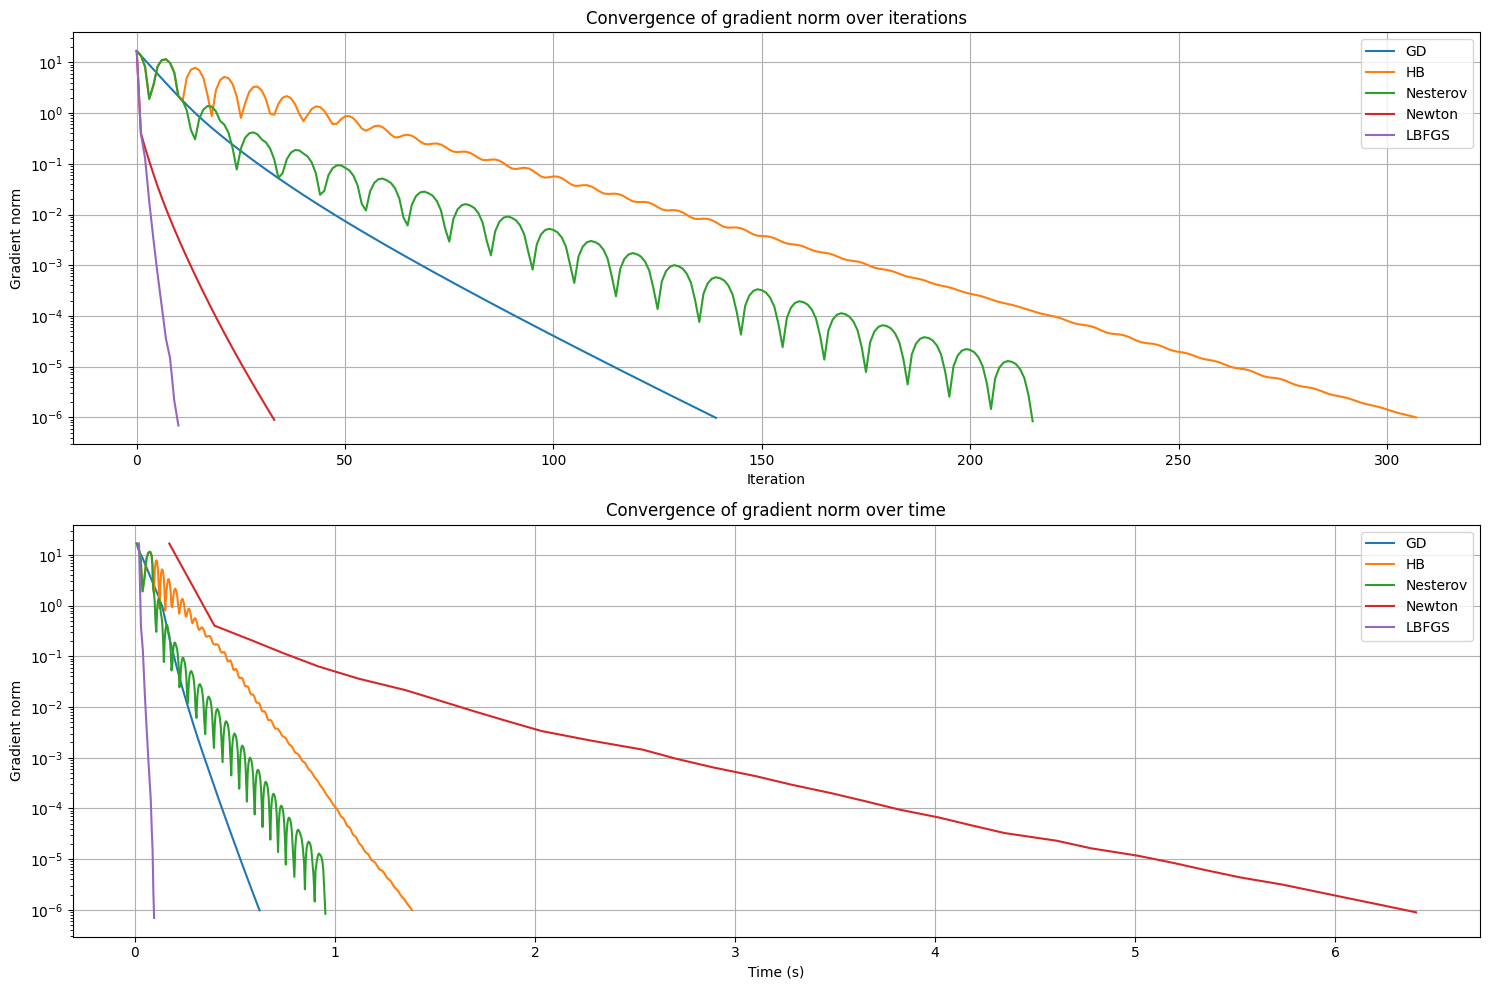

In [10]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
for name, history in conv_grad_norms.items():
    plt.semilogy(history, label=name)
plt.legend()
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gradient norm")
plt.title("Convergence of gradient norm over iterations")

plt.subplot(2, 1, 2)
for name, times in conv_times.items():
    plt.semilogy(times, conv_grad_norms[name], label=name)
plt.legend()
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel("Gradient norm")
plt.title("Convergence of gradient norm over time")

plt.tight_layout()
plt.show()

### Комментарии
При подборе оптимального $\alpha=\frac{1}{L}$ в методе градиентного спуска, он начинает выигрывать по скорости сходимости у метода тяжелого шарика и Нестерова. 

Также из графиков видно, что по количеству итераций методы Ньютона и LBFGS однозначно выигрывают методы, учитывающие только градиент. Однако, по времени работы метод Ньютона крайне неэффективен, так как вычисление обратного гессиана занимает кубическое время. У LBFGS такой проблемы нет: он наиболее эффективен по времени работы и по количеству итераций.